

# Experiment: Pre-Training vs. Specialization for Time Series Prediction with Diverse Generators

## Overview
This experiment builds on the previous notebook, where we compared the effectiveness of pre-training on synthetic generators versus specializing on limited target data for time series prediction. Here, we expand the scope by:
1. Using **10 diverse generators** with different distributions for pre-training.
2. Setting **real stock daily price data** as the target generator, simulating a real-world, unpredictable environment.

The goal is to evaluate whether pre-training on a wide variety of synthetic time series improves performance when fine-tuned on limited data from the real-world target generator.

---

## Target Generator
- **Real Stock Data**: Daily closing prices from selected stocks (e.g., S&P 500 constituents).
- Each time series represents 50 consecutive days of prices: `s = [s_1, s_2, ..., s_50]`.
- The task is to predict the final day’s price (`s_50`) using the first 49 days (`[s_1, s_2, ..., s_49]`).

---

## Pre-Training Generators
### Generators for Pre-Training Data
We will use 10 synthetic generators to produce pre-training data. Each generator outputs time series with length 50 but from distinct distributions:
1. **Gaussian Generators**:
   - `N(0, 5)`, `N(10, 15)`, `N(5, 10)`.
2. **Log-Normal Generators**:
   - `LogNormal(0, 1)`, `LogNormal(1, 2)`.
3. **Uniform Generators**:
   - `Uniform(0, 1)`, `Uniform(5, 10)`.
4. **Exponential Generators**:
   - `Exponential(λ=1)`, `Exponential(λ=2)`.
5. **Mixture Generators**:
   - A combination of Gaussian and uniform distributions.

These generators simulate diverse time series behaviors, from smooth trends to high variability and noise.

---

## Datasets

1. **Dataset A (Specialized Training)**:
   - A limited set of time series from real stock data (target generator).
   - Represents specialized training on the target environment.

2. **Dataset B (Pre-Training Data)**:
   - Synthetic time series from the 10 alternative generators described above.
   - Represents pre-training data from unrelated but diverse distributions.

---

## Hypotheses
1. **Pre-Training Hypothesis**:
   - Pre-training on diverse generators will teach the model general time series prediction principles.
   - Fine-tuning on the limited target data (Dataset A) will further refine the model, improving performance on real stock data.

2. **Specialization Hypothesis**:
   - A model trained only on limited real stock data (Dataset A) will perform better, as it directly focuses on the target distribution.

---

## Models
We will compare three models:
1. **Model A (Specialized Training)**:
   - Trained only on Dataset A (limited real stock data).

2. **Model B (Pre-Training Only)**:
   - Trained exclusively on Dataset B (synthetic generators).

3. **Model C (Pre-Training + Fine-Tuning)**:
   - Pre-trained on Dataset B and then fine-tuned on Dataset A.

---

## Experiment Steps

### **Step 1: Data Generation**
1. **Synthetic Data**:
   - Generate 10 datasets from the pre-training generators, each containing 10,000 time series of length 50.
2. **Real Stock Data**:
   - Select historical stock price data for the target generator (e.g., S&P 500 constituents).
   - Split into training, validation, and test sets.

### **Step 2: Model Training**
1. Train **Model A** on Dataset A (real stock data only).
2. Train **Model B** on Dataset B (synthetic generators only).
3. Train **Model C** in two phases:
   - **Pre-Training**: Train on Dataset B (synthetic generators).
   - **Fine-Tuning**: Fine-tune on Dataset A (real stock data).

### **Step 3: Evaluation**
- Evaluate all models on a **held-out test set** of real stock data (unseen during training).
- Metrics:
  - Mean Squared Error (MSE) for predicting `s_50`.
  - Generalization performance on diverse stocks (e.g., from different industries).

---

## Implementation Details

### **Model Architecture**
- **Input**: First 49 values of the time series (`[s_1, s_2, ..., s_49]`).
- **Output**: Predicted final value (`s_50`).
- **Architecture**:
  - LSTM/Transformer-based model for capturing temporal dependencies.
  - Dense layers for prediction.

### **Training Configuration**
- **Loss Function**: Mean Squared Error (MSE).
- **Optimizer**: Adam.
- **Learning Rate**: Tuned for each model.
- **Training Epochs**: Early stopping based on validation performance.

---

## Analysis and Expected Outcomes

1. **Model A (Specialized Training)**:
   - Likely to perform well on the test set but may overfit due to limited training data.

2. **Model B (Pre-Training Only)**:
   - Expected to generalize poorly to the target generator due to domain mismatch.

3. **Model C (Pre-Training + Fine-Tuning)**:
   - Expected to outperform both Model A and Model B by leveraging general time series principles from pre-training and adapting to the target distribution via fine-tuning.



In [1]:
import numpy as np
import pandas as pd
import yfinance as yf  # For fetching real stock data

# Parameters
time_series_length = 50
num_samples_target = 1000  # Number of time series from the target generator (real stock data)
num_samples_pretraining = 100000  # Number of time series from alternative generators

# Step 1: Fetch Real Stock Data (Target Generator)
def fetch_stock_data(ticker, start_date, end_date):
    """
    Fetches daily closing price data for a given stock from Yahoo Finance.
    """
    stock_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    return stock_data['Close'].values

def generate_target_series_from_stock(stock_data, time_series_length, num_samples):
    """
    Slices the stock data into time series of fixed length.
    """
    time_series = []
    for i in range(len(stock_data) - time_series_length):
        time_series.append(stock_data[i:i + time_series_length])
    # Randomly sample `num_samples` time series
    np.random.shuffle(time_series)
    return np.array(time_series[:num_samples])

# Fetch stock data
ticker = "AAPL"  # Example: Apple stock
start_date = "2010-01-01"
end_date = "2020-12-31"
stock_data = fetch_stock_data(ticker, start_date, end_date)

# Generate target data
target_data = generate_target_series_from_stock(stock_data, time_series_length, num_samples_target)

# Step 2: Generate Data from 10 Alternative Generators
def generate_10_alternative_series(num_samples, time_series_length):
    """
    Generates time series from 10 different alternative generators with varied distributions.
    """
    num_samples_per_generator = num_samples // 10

    # Define 10 diverse generators
    generators = [
        np.random.normal(loc=0, scale=5, size=(num_samples_per_generator, time_series_length)),  # Gaussian
        np.random.normal(loc=10, scale=15, size=(num_samples_per_generator, time_series_length)),  # Gaussian
        np.random.lognormal(mean=0, sigma=1, size=(num_samples_per_generator, time_series_length)),  # Log-Normal
        np.random.lognormal(mean=1, sigma=2, size=(num_samples_per_generator, time_series_length)),  # Log-Normal
        np.random.uniform(low=0, high=1, size=(num_samples_per_generator, time_series_length)),  # Uniform
        np.random.uniform(low=5, high=10, size=(num_samples_per_generator, time_series_length)),  # Uniform
        np.random.exponential(scale=1, size=(num_samples_per_generator, time_series_length)),  # Exponential
        np.random.exponential(scale=2, size=(num_samples_per_generator, time_series_length)),  # Exponential
        np.random.normal(loc=0, scale=1, size=(num_samples_per_generator, time_series_length)) + 
        np.random.uniform(low=-1, high=1, size=(num_samples_per_generator, time_series_length)),  # Mixture: Gaussian + Uniform
        np.random.normal(loc=5, scale=2, size=(num_samples_per_generator, time_series_length)) + 
        np.random.exponential(scale=1, size=(num_samples_per_generator, time_series_length))  # Mixture: Gaussian + Exponential
    ]

    # Combine all generated data
    return np.vstack(generators)

# Generate alternative data
alternative_data = generate_10_alternative_series(num_samples_pretraining, time_series_length)

# Shuffle the dataset
np.random.shuffle(alternative_data)

# Step 3: Convert to Pandas DataFrame
target_df = pd.DataFrame(target_data, columns=[f"s_{i+1}" for i in range(time_series_length)])
alternative_df = pd.DataFrame(alternative_data, columns=[f"s_{i+1}" for i in range(time_series_length)])

# Output dataset shapes for verification
target_df.shape, alternative_df.shape


((1000, 50), (100000, 50))

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Data Preparation


# Split the target generator data into training and testing sets
X_target = target_df.iloc[:, :-1]  # Input: s_1 to s_49
y_target = target_df.iloc[:, -1]   # Output: s_50
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(X_target, y_target, test_size=0.3, random_state=42)

# Split the alternative generator data into training and validation sets
X_alternative = alternative_df.iloc[:, :-1]  # Input: s_1 to s_49
y_alternative = alternative_df.iloc[:, -1]   # Output: s_50

# Scale X data
target_scaler = StandardScaler()
X_train_target = target_scaler.fit_transform(X_train_target)
X_test_target = target_scaler.transform(X_test_target)

alternative_scaler = StandardScaler()
X_alternative = alternative_scaler.fit_transform(X_alternative)




# print shapes of the datasets
print("X_train_target shape:", X_train_target.shape)
print("y_train_target shape:", y_train_target.shape)
print("X_test_target shape:", X_test_target.shape)
print("y_test_target shape:", y_test_target.shape)

print("X_alternative shape:", X_alternative.shape)
print("y_alternative shape:", y_alternative.shape)




X_train_target shape: (700, 49)
y_train_target shape: (700,)
X_test_target shape: (300, 49)
y_test_target shape: (300,)
X_alternative shape: (100000, 49)
y_alternative shape: (100000,)


In [3]:
from sklearn.neural_network import MLPRegressor

# Model Training
print("Training models...")

# Model A: Train on target generator data
model_a = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
model_a.fit(X_train_target, y_train_target)

print('Model A Trained')

# Model B: Train on alternative generators' data
model_b = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
model_b.fit(X_alternative, y_alternative)

print('Model B Trained')

# Model C: Pre-train on alternative generators, fine-tune on target generator
model_c = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=42)
# Pre-train on alternative generators
model_c.fit(X_alternative, y_alternative)
# Fine-tune on target generator
model_c.partial_fit(X_train_target, y_train_target)

print('Model C Trained')

print("Training complete.")

Training models...


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model A Trained


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model B Trained
Model C Trained
Training complete.


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [5]:
from sklearn.metrics import mean_squared_error
# Evaluation

# Predict and evaluate on out-of-sample data from the target generator
y_pred_a = model_a.predict(X_test_target)
y_pred_b = model_b.predict(X_test_target)
y_pred_c = model_c.predict(X_test_target)

mse_a = mean_squared_error(y_test_target, y_pred_a)
mse_b = mean_squared_error(y_test_target, y_pred_b)
mse_c = mean_squared_error(y_test_target, y_pred_c)

# Print results
print("Model A (Trained on target generator): MSE =", mse_a)
print("Model B (Trained on alternative generators): MSE =", mse_b)
print("Model C (Pre-trained on alternative generators, fine-tuned on target generator): MSE =", mse_c)

Model A (Trained on target generator): MSE = 2.763496176614559
Model B (Trained on alternative generators): MSE = 1137.1248157983973
Model C (Pre-trained on alternative generators, fine-tuned on target generator): MSE = 1024.9793488247133


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Parameters
n_runs = 10
time_series_length = 50
num_samples_target = 1000  # Real stock data
num_samples_pretraining = 100000  # Synthetic generators

# Results storage
mse_a_list = []
mse_b_list = []
mse_c_list = []

# Multiple runs
for i in range(n_runs):
    print(f"Run {i + 1}/{n_runs}")

    # Fetch stock data for the target generator
    ticker = "AAPL"  # Example: Apple stock
    start_date = "2010-01-01"
    end_date = "2020-12-31"
    stock_data = fetch_stock_data(ticker, start_date, end_date)
    target_data = generate_target_series_from_stock(stock_data, time_series_length, num_samples_target)

    # Generate data from 10 alternative generators
    alternative_data = generate_10_alternative_series(num_samples_pretraining, time_series_length)

    # Shuffle the datasets
    np.random.shuffle(alternative_data)

    # Convert to DataFrame
    target_df = pd.DataFrame(target_data, columns=[f"s_{i + 1}" for i in range(time_series_length)])
    alternative_df = pd.DataFrame(alternative_data, columns=[f"s_{i + 1}" for i in range(time_series_length)])

    # Split the target generator data into training and testing sets
    X_target = target_df.iloc[:, :-1]  # Input: s_1 to s_49
    y_target = target_df.iloc[:, -1]   # Output: s_50
    X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
        X_target, y_target, test_size=0.3, random_state=i
    )

    # Split the alternative generator data into training sets
    X_alternative = alternative_df.iloc[:, :-1]  # Input: s_1 to s_49
    y_alternative = alternative_df.iloc[:, -1]   # Output: s_50

    # Scale X data
    target_scaler = StandardScaler()
    X_train_target = target_scaler.fit_transform(X_train_target)
    X_test_target = target_scaler.transform(X_test_target)

    alternative_scaler = StandardScaler()
    X_alternative = alternative_scaler.fit_transform(X_alternative)

    # Model Training
    # Model A: Trained only on target generator
    model_a = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=i)
    model_a.fit(X_train_target, y_train_target)

    # Model B: Trained only on alternative generators
    model_b = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=i)
    model_b.fit(X_alternative, y_alternative)

    # Model C: Pre-trained on alternative generators, fine-tuned on target generator
    model_c = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=500, random_state=i)
    model_c.fit(X_alternative, y_alternative)  # Pre-training
    model_c.partial_fit(X_train_target, y_train_target)  # Fine-tuning

    # Evaluation
    y_pred_a = model_a.predict(X_test_target)
    y_pred_b = model_b.predict(X_test_target)
    y_pred_c = model_c.predict(X_test_target)

    mse_a = mean_squared_error(y_test_target, y_pred_a)
    mse_b = mean_squared_error(y_test_target, y_pred_b)
    mse_c = mean_squared_error(y_test_target, y_pred_c)

    mse_a_list.append(mse_a)
    mse_b_list.append(mse_b)
    mse_c_list.append(mse_c)

# Print results
print("Model A (Trained on target generator): Mean MSE =", np.mean(mse_a_list))
print("Model B (Trained on alternative generators): Mean MSE =", np.mean(mse_b_list))
print("Model C (Pre-trained on alternative generators, fine-tuned on target generator): Mean MSE =", np.mean(mse_c_list))

# Print standard deviation
print("Model A (Trained on target generator): Standard Deviation =", np.std(mse_a_list))
print("Model B (Trained on alternative generators): Standard Deviation =", np.std(mse_b_list))
print("Model C (Pre-trained on alternative generators, fine-tuned on target generator): Standard Deviation =", np.std(mse_c_list))


Run 1/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Run 2/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Run 3/10
Run 4/10


...

Run 9/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Run 10/10


c:\Users\JanderM\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Model A (Trained on target generator): Mean MSE = 3.28001837701508
Model B (Trained on alternative generators): Mean MSE = 809296.2888912698
Model C (Pre-trained on alternative generators, fine-tuned on target generator): Mean MSE = 499918.44189647306
Model A (Trained on target generator): Standard Deviation = 1.3900104338120698
Model B (Trained on alternative generators): Standard Deviation = 2330688.1566182533
Model C (Pre-trained on alternative generators, fine-tuned on target generator): Standard Deviation = 1490811.6626666759


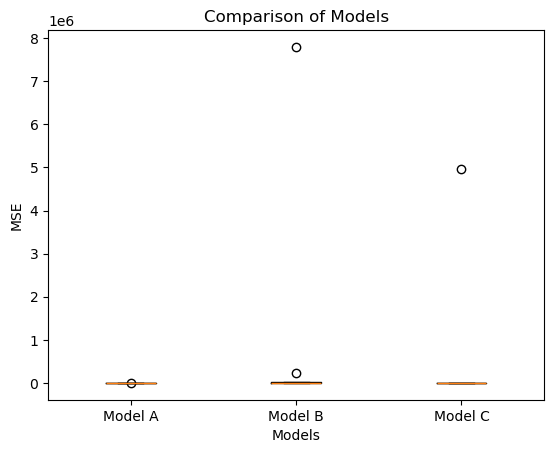

In [12]:
from matplotlib import pyplot as plt

# Box plot of MSE
plt.boxplot([mse_a_list, mse_b_list, mse_c_list])
plt.xticks([1, 2, 3], ['Model A', 'Model B', 'Model C'])
plt.xlabel('Models')
plt.ylabel('MSE')
plt.title('Comparison of Models')
plt.show()

In [13]:
print(mse_a_list)
print(mse_b_list)
print(mse_c_list)

[1.6689084688739473, 3.5671657154338314, 2.0047707022313843, 3.979704336143456, 6.443142938678605, 2.9780237384414363, 4.748406466027074, 2.902830299217696, 2.3661912184527325, 2.1410398866506397]
[15156.17481861523, 2044.1350432397323, 1451.1082167439893, 240533.90220243056, 1631.9238739982734, 4264.698511099435, 15755.808678834313, 7798215.124752893, 1471.3168807196125, 12438.69593412362]
[5269.187873617193, 917.3236057209922, 1383.1814814178126, 1359.3888073012217, 1416.6183193934, 3287.539013499291, 4944.195942301077, 4972349.399424583, 1269.5653635693952, 6988.019133327885]


In [ ]:
# are the results due to not enough data?
# what other configuration might lead to a positive  result?